In [3]:
from OptimumFilter import *
from trace_IO import *
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

sampling_frequency = 3906250
template = np.load("/home/dwong/DELight_mtr/trigger_study/wk15/templates/vac_ch_template.npy")
noise_psd = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
vac_of = OptimumFilter(template, noise_psd, sampling_frequency)

In [15]:
data = np.load("validation_trace.npz")
example = data["raw"]
fit_ampl = data["ampl"]
injection = data["inject"].item()  

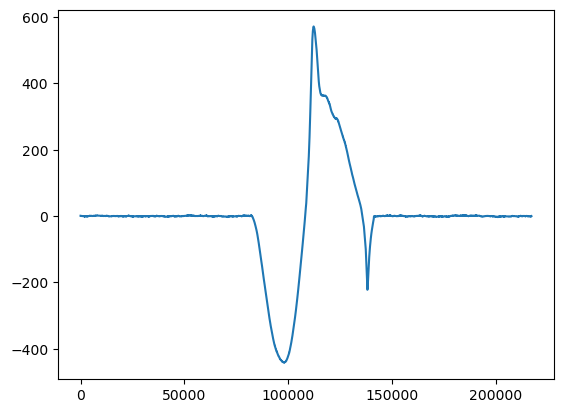

In [5]:
plt.plot(fit_ampl)

In [6]:
a, b, c = vac_of.sliding_fit(example)

107027
108616
205268


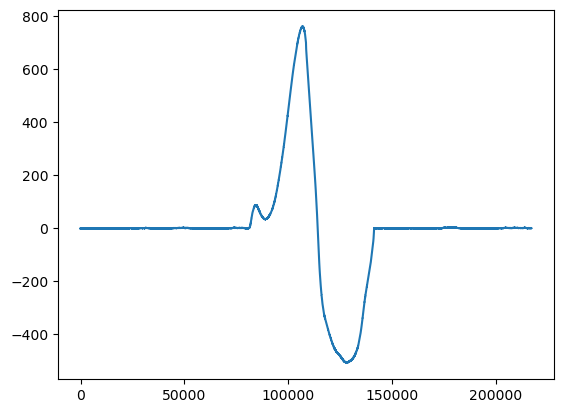

In [9]:
plt.plot(a)
print(np.argmax(a))
print(idx)
print(np.argmin(b))

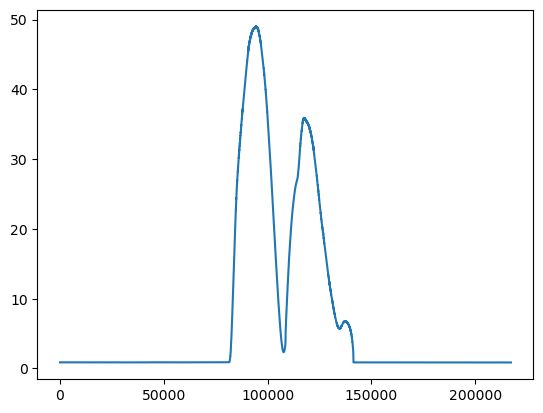

In [10]:
plt.plot(b)

In [25]:
import numpy as np

def deepest_valley_idx(chisq: np.ndarray, win: int = 4097) -> int:
    """
    Return index of the dominant local minimum ("big drop") in chisq.
    Uses a wide moving-average baseline via cumulative sums (fast, no SciPy).

    win: baseline window (must be odd). Choose >> dip width (e.g., 2049–8193).
    """
    y = np.asarray(chisq, dtype=float)
    win = int(win) | 1  # force odd

    # moving average via cumulative sum (valid region)
    c = np.cumsum(np.insert(y, 0, 0.0))
    ma_valid = (c[win:] - c[:-win]) / win

    # pad to 'same' length by extending edges
    pad = win // 2
    baseline = np.pad(ma_valid, (pad, pad), mode='edge')

    drop = baseline - y
    return int(np.argmax(drop))

In [30]:
idx= deepest_valley_idx(b)
print(idx)

108616


In [32]:
injection

108616

In [29]:
b

array([0.88054228, 0.88055053, 0.88055308, ..., 0.86464393, 0.86468334,
       0.86464996])